In [11]:
!pip install sentence-transformers

In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [14]:
sentences = [
    # Cricket
    "The bowler delivered a perfect yorker to take the wicket.",
    "The batsman scored a century in the match.",
    "Fielders played a crucial role in saving runs.",

    # Cooking
    "Cooking pasta requires boiling water and adding salt.",
    "Baking a cake needs precise measurements.",
    "Spices enhance the flavor of any dish.",

    # Cybersecurity
    "Strong passwords are essential for online security.",
    "Phishing attacks trick users into revealing data.",
    "Encryption protects sensitive information.",
    "Firewalls help prevent unauthorized access to networks."
]

In [16]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
embeddings = model.encode(sentences)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

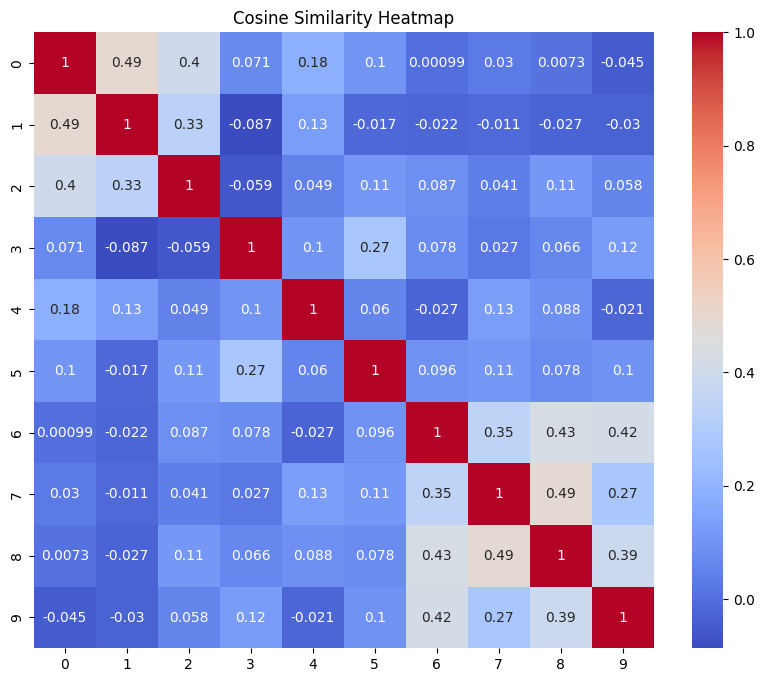

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Heatmap")
plt.show()

In [24]:
query = "The bowler took three wickets in one over"

In [26]:
query_embedding = model.encode([query])

In [28]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [29]:
top_indices = similarities.argsort()[-2:][::-1]

print("Top 2 similar sentences:\n")
for i in top_indices:
    print(sentences[i], "-> Score:", similarities[i])

Top 2 similar sentences:

The bowler delivered a perfect yorker to take the wicket. -> Score: 0.6850507
The batsman scored a century in the match. -> Score: 0.56114495
